In [1]:
import os, sys, pickle, emcee, copy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pyswarms as ps

from lenstronomy.Util import param_util
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Workflow.fitting_sequence import FittingSequence
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.Plots.model_plot import ModelPlot

sys.path.append("../src")

from iful.util import *
from iful.image_set import *
from iful.flat_modeling import *

In [2]:
with open("s4_models/imset4.pickle", "rb") as handle:
    imset4 = pickle.load(handle)

if Path("s4_models/flatshapeletsmodel4.pickle").exists():
    with open("s4_models/flatshapeletsmodel4.pickle", "rb") as handle:
        flatmodel4 = pickle.load(handle)
else:
    flatmodel4 = FlatModel(
        imset4, ["EPL_Q_PHI", "SIS", "SHEAR"], ["SERSIC_ELLIPSE", 'SHAPELETS_ELLIPSE']
    )

In [3]:
from astropy.cosmology import FlatLambdaCDM
from lenstronomy.Cosmo.lens_cosmo import LensCosmo

lensCosmo = LensCosmo(
    cosmo=FlatLambdaCDM(H0=70, Om0=0.3),
    z_lens=imset4.aux_info["zl"],
    z_source=imset4.zs,
)

vd = 261
vd_err = 3
ld_ein_d = lensCosmo.dds / lensCosmo.ds * 4 * np.pi * vd**2 / 299792**2 * 206265
ld_ein_d_err = (lensCosmo.dds / lensCosmo.ds * 4 * np.pi * 2 * vd * vd_err / 299792**2 * 206265)

vd = 313
vd_err = 4
ld_ein_f = lensCosmo.dds / lensCosmo.ds * 4 * np.pi * vd**2 / 299792**2 * 206265
ld_ein_f_err = (lensCosmo.dds / lensCosmo.ds * 4 * np.pi * 2 * vd * vd_err / 299792**2 * 206265)

init_lens_center_pix = flatmodel4.convert_pixel_to_ra_dec(imset4.aux_info["init_lens_center"])

print(f"theta_d = {ld_ein_d:.3f} +- {ld_ein_d_err:.3f}")
print(f"theta_f = {ld_ein_f:.3f} +- {ld_ein_f_err:.3f}")

theta_d = 1.104 +- 0.025
theta_f = 1.588 +- 0.041


In [4]:
lens_model_list = flatmodel4.lensmodel
source_model_list = flatmodel4.sourcemodel
point_source_list = []
lens_light_model_list = []

threadCount = 56

In [5]:
fixed_lens = []
kwargs_lens_init = []
kwargs_lens_sigma = []
kwargs_lower_lens = []
kwargs_upper_lens = []

kwargs_constraints = {"linear_solver": True}

joint_source_with_source = []
joint_source_with_source.append([0, 1, ['center_x', 'center_y', 'e1', 'e2']])
kwargs_constraints['joint_source_with_source'] = joint_source_with_source

fixed_lens.append({})
kwargs_lens_init.append({"theta_E": 1.28476891e+01,"gamma": 1.44320788,"q": 8.40578732e-01,"phi": -1.41771961e+00,"center_x": -7.37539089e-01,"center_y": -1.68323964e-01})
kwargs_lower_lens.append({"theta_E": 9,"gamma": 1,"q": 0,"phi": -1 * np.pi,"center_x": -5,"center_y": -5,})
kwargs_upper_lens.append({"theta_E": 18, "gamma": 3, "q": 1, "phi": np.pi, "center_x": 5, "center_y": 5})
kwargs_lens_sigma.append({"theta_E": 0.1,"gamma": 0.1,"q": 0.1,"phi": 0.1,"center_x": 0.1,"center_y": 0.1,})

# fixed_lens.append({"center_x": kwargs_lens[1]['center_x'], "center_y": kwargs_lens[1]['center_y'], 'theta_E': ld_ein_d})
# kwargs_lens_init.append(kwargs_lens[1])
# kwargs_lower_lens.append({"theta_E": 0, "center_x": -100, "center_y": -100})
# kwargs_upper_lens.append({"theta_E": 3, "center_x": 100, "center_y": 100})
# kwargs_lens_sigma.append({"theta_E": 0.1, "center_x": 0.1, "center_y": 0.1})

fixed_lens.append({"center_x": init_lens_center_pix[1, 0], "center_y": init_lens_center_pix[1, 1], 'theta_E': ld_ein_f})
kwargs_lens_init.append({"center_x": init_lens_center_pix[1, 0], "center_y": init_lens_center_pix[1, 1], 'theta_E': ld_ein_f})
kwargs_lower_lens.append({"theta_E": 0, "center_x": -100, "center_y": -100})
kwargs_upper_lens.append({"theta_E": 5, "center_x": 100, "center_y": 100})
kwargs_lens_sigma.append({"theta_E": 0.1, "center_x": 0.1, "center_y": 0.1})

fixed_lens.append({"ra_0": 0, "dec_0": 0})
kwargs_lens_init.append({"gamma1": 1.11584811e-02, "gamma2": 2.21064366e-02})
kwargs_lens_sigma.append({"gamma1": 0.1, "gamma2": 0.1})
kwargs_lower_lens.append({"gamma1": -0.2, "gamma2": -0.2})
kwargs_upper_lens.append({"gamma1": 0.2, "gamma2": 0.2})

lens_params = [
    kwargs_lens_init,
    kwargs_lens_sigma,
    fixed_lens,
    kwargs_lower_lens,
    kwargs_upper_lens,
]

fixed_source = []
kwargs_source_init = []
kwargs_source_sigma = []
kwargs_lower_source = []
kwargs_upper_source = []

fixed_source.append({})
kwargs_source_init.append({"n_sersic": 4, "R_sersic": 2.44630971e-01, "e1": -1.56396001e-01, "e2": -1.05667431e-01, "center_x": 9.82161677e-01, "center_y": -1.27656025e+00})
kwargs_source_sigma.append({"n_sersic": 1,"R_sersic": 0.3,"e1": 0.05,"e2": 0.05,"center_x": 0.1,"center_y": 0.1,})
kwargs_lower_source.append({"e1": -0.75,"e2": -0.75,"R_sersic": 0.001,"n_sersic": 0.1,"center_x": 9.82161677e-01 - 5,"center_y": -1.27656025e+00 - 5,})
kwargs_upper_source.append({"e1": 0.75,"e2": 0.75,"R_sersic": 10,"n_sersic": 10.0,"center_x": 9.82161677e-01 + 5,"center_y": -1.27656025e+00 + 5,})

fixed_source.append({'n_max': 3})
kwargs_source_init.append({'beta': 0.13, "e1": -1.56396001e-01, "e2": -1.05667431e-01, "center_x": 9.82161677e-01, "center_y": -1.27656025e+00})
kwargs_source_sigma.append({'beta': 0.05, 'e1': 0.05, 'e2': 0.05, 'center_x': 0.1, 'center_y': 0.1})
kwargs_lower_source.append({'beta': 1e-10, 'e1': -0.75, 'e2': -0.75, 'center_x': 9.82161677e-01-1, 'center_y': -1.27656025e+00-1})
kwargs_upper_source.append({'beta': 10, 'e1': 0.75, 'e2': 0.75, 'center_x': 9.82161677e-01+1, 'center_y': -1.27656025e+00+1})

source_params = [
    kwargs_source_init,
    kwargs_source_sigma,
    fixed_source,
    kwargs_lower_source,
    kwargs_upper_source,
]

lens_light_params = [[], [], [], [], []]
ps_params = [[], [], [], [], []]

kwargs_params = {
    "lens_model": lens_params,
    "source_model": source_params,
    "lens_light_model": lens_light_params,
    "point_source_model": ps_params,
}

# gaussian_prior_list = (
#     [[1, 'theta_E', ld_ein_d, ld_ein_d_err], [2, 'theta_E', ld_ein_f, ld_ein_f_err]]
# )  

In [6]:
kwargs_likelihood = {
    "image_likelihood_mask_list": np.array([imset4.mask]),
    "check_positive_flux": True,
    # "prior_lens": gaussian_prior_list,
}  
kwargs_model = {
    "lens_model_list": lens_model_list,
    "source_light_model_list": source_model_list,
    "lens_light_model_list": lens_light_model_list,
    "point_source_model_list": point_source_list,
    "fixed_magnification_list": [False],
}

multi_band_list = [flatmodel4.multi_band_list]
kwargs_data_joint = {
    "multi_band_list": multi_band_list,
    "multi_band_type": "single-band",
}

fitting_seq = FittingSequence(
    kwargs_data_joint,
    kwargs_model,
    kwargs_constraints,
    kwargs_likelihood,
    kwargs_params,
)

fitting_kwargs_list = [["PSO",{"sigma_scale": 1,"n_particles": 3000,"n_iterations": 3000,"threadCount": threadCount,}]]

if flatmodel4.init_pso_fit is None:
    chain_list = fitting_seq.fit_sequence(fitting_kwargs_list)
    kwargs_result = fitting_seq.best_fit()
    flatmodel4.init_pso_fit = kwargs_result
    flatmodel4.init_pso_fitting_seq = fitting_seq
else:
    kwargs_result = flatmodel4.init_pso_fit
    fitting_seq = flatmodel4.init_pso_fitting_seq

In [7]:
print("checking lens params")
[
    check_near_bounds(
        kwargs_result["kwargs_lens"][i], kwargs_lower_lens[i], kwargs_upper_lens[i], i
    )
    for i in np.arange(len(kwargs_lower_lens))
]

print("checking source params")
[
    check_near_bounds(
        kwargs_result["kwargs_source"][i],
        kwargs_lower_source[i],
        kwargs_upper_source[i],
        i,
    )
    for i in np.arange(len(kwargs_upper_source))
]

checking lens params
checking source params


[None, None]

-4.047568448415409 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  4.047568448415409


/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:68: RuntimeWarning: divide by zero encountered in log10
  log_model = np.log10(model)
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:68: RuntimeWarning: invalid value encountered in log10
  log_model = np.log10(model)
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:161: RuntimeWarning: divide by zero encountered in log10
  np.log10(self._data),
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:161: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:225: RuntimeWarning: divide by zero encountered in log10
  np.log10(self._model),
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/s

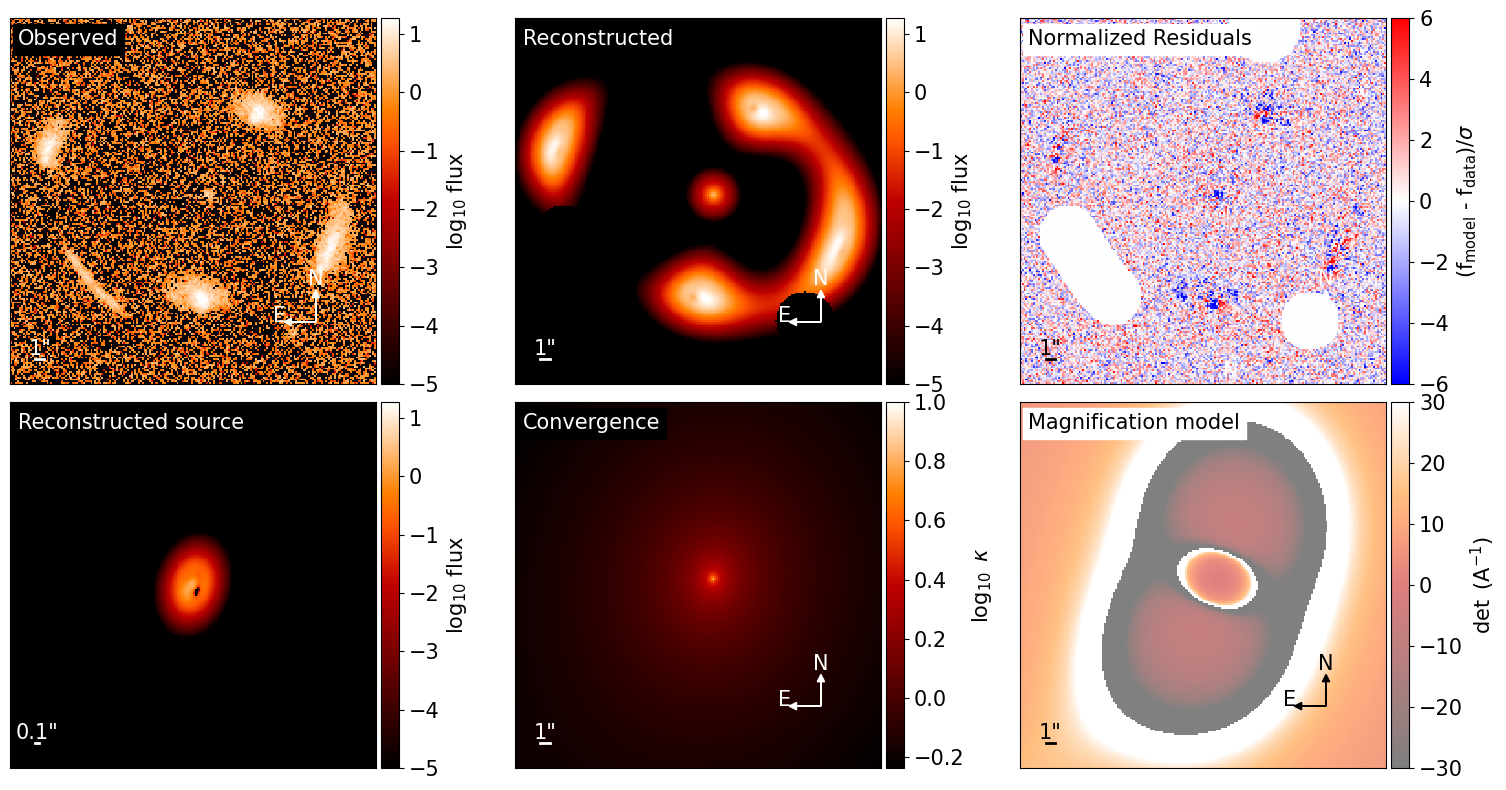

/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:1121: RuntimeWarning: divide by zero encountered in log10
  np.log10(model),
/global/homes/w/wsheu1/.conda/envs/iful/lib/python3.11/site-packages/lenstronomy/Plots/model_band_plot.py:1121: RuntimeWarning: invalid value encountered in log10
  np.log10(model),


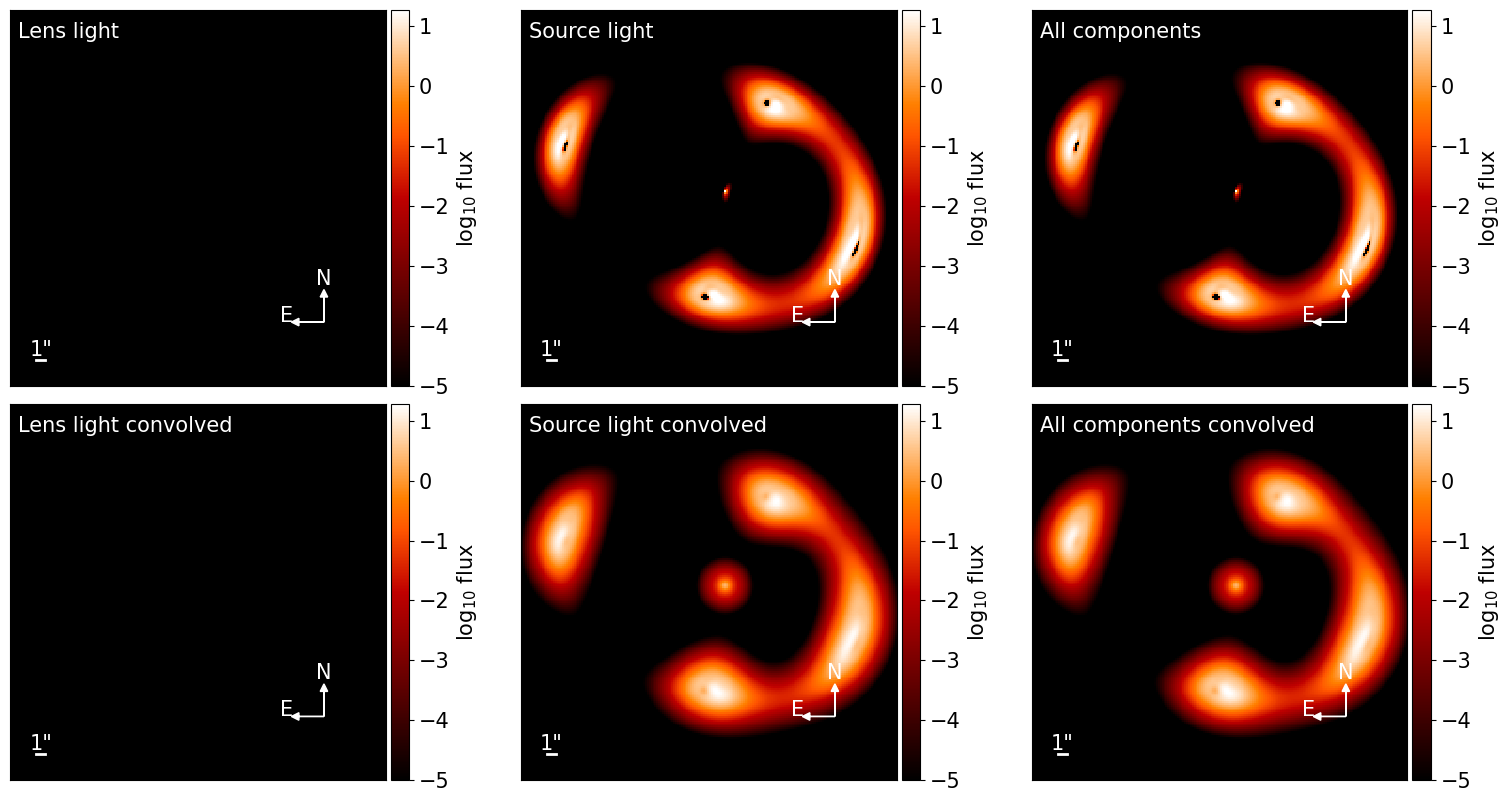

{'kwargs_lens': [{'theta_E': np.float64(12.81020487525542), 'gamma': np.float64(1.4075422199293743), 'q': np.float64(0.8355350166975738), 'phi': np.float64(-1.4218774501011229), 'center_x': np.float64(-0.7446481784236493), 'center_y': np.float64(-0.1820923721627748)}, {'theta_E': np.float64(1.5876356460893257), 'center_x': np.float64(27.399999567933264), 'center_y': np.float64(-28.999999808979737)}, {'gamma1': np.float64(0.0017144340980256069), 'gamma2': np.float64(0.016794184773137315), 'ra_0': 0, 'dec_0': 0}], 'kwargs_source': [{'amp': np.float64(698.9139249366715), 'R_sersic': np.float64(0.2319944990371567), 'n_sersic': np.float64(0.6541820030888091), 'e1': np.float64(-0.14589799747080928), 'e2': np.float64(-0.08035861401695552), 'center_x': np.float64(0.8439225686590461), 'center_y': np.float64(-1.1637501439911913)}, {'amp': array([-2514.48751159,   557.27313149,   -75.448666  ,  -258.44315158,
        -348.74104813,  -434.14149581,   -27.81266438,  -169.26758418,
         129.2931

In [8]:
modelPlot = ModelPlot(
    fitting_seq.multi_band_list,
    kwargs_model,
    kwargs_result,
    arrow_size=0.02,
    cmap_string="gist_heat",
    linear_solver=kwargs_constraints.get("linear_solver", True),
    image_likelihood_mask_list=np.array([imset4.mask]),
)

# multi_band_list_sim = copy.deepcopy(multi_band_list)
psfk_f160w_init = fitting_seq.multi_band_list[0][1]
# multi_band_list_sim[0][1] = psfk_f475x

f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)

modelPlot.data_plot(ax=axes[0, 0])
modelPlot.model_plot(ax=axes[0, 1])
modelPlot.normalized_residual_plot(ax=axes[0, 2], v_min=-6, v_max=6)
modelPlot.source_plot(ax=axes[1, 0], deltaPix_source=0.05, numPix=200)
modelPlot.convergence_plot(ax=axes[1, 1], v_max=1)
modelPlot.magnification_plot(ax=axes[1, 2], v_min=-30, v_max=30)
f.tight_layout()
f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.0, hspace=0.05)
plt.show()

f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)

modelPlot.decomposition_plot(
    ax=axes[0, 0], text="Lens light", lens_light_add=True, unconvolved=True
)
modelPlot.decomposition_plot(
    ax=axes[1, 0], text="Lens light convolved", lens_light_add=True
)
modelPlot.decomposition_plot(
    ax=axes[0, 1], text="Source light", source_add=True, unconvolved=True
)
modelPlot.decomposition_plot(
    ax=axes[1, 1], text="Source light convolved", source_add=True
)
modelPlot.decomposition_plot(
    ax=axes[0, 2],
    text="All components",
    source_add=True,
    lens_light_add=True,
    unconvolved=True,
)
modelPlot.decomposition_plot(
    ax=axes[1, 2],
    text="All components convolved",
    source_add=True,
    lens_light_add=True,
    point_source_add=True,
)
f.tight_layout()
f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.0, hspace=0.05)
plt.show()

print(kwargs_result)
# print(get_p_value(fitting_seq, kwargs_model, mask))

In [9]:
with open("s4_models/flatshapeletsmodel4.pickle", "wb") as handle:
    pickle.dump(flatmodel4, handle, protocol=pickle.HIGHEST_PROTOCOL)

# MCMC

In [10]:
bf = f"s4_models/flatshapelets_model_backup.hdf5"

multi_band_list_sim = copy.deepcopy(fitting_seq.multi_band_list)

first = not os.path.isfile(bf)
convergence = False
convergence_final = False
walker_ratio = 15

converged_b4 = os.path.isfile(f"s4_models/flatshapelets_chains.pickle")

max_interations, moves = 300, [(emcee.moves.StretchMove(), 1.0)]

if not os.path.isfile(f"s4_models/bandend_shapelets_i.txt"):
    os.system(f"touch s4_models/bandend_shapelets_i.txt")
    with open(f"s4_models/bandend_shapelets_i.txt", "w") as f:
        f.write("0")
with open(f"s4_models/bandend_shapelets_i.txt") as f:
    bandend_i = int(f.readlines()[-1])

while True:
    if not converged_b4:
        bandend_i += 1
        print(f"run {bandend_i}")

    if converged_b4:
        fitting_kwargs_list = [
            ["update_settings", {"kwargs_likelihood": {"prior_lens": []}}],
            [
                "MCMC",
                {
                    "n_burn": 0,
                    "n_run": 0,
                    "walkerRatio": walker_ratio,
                    "sigma_scale": 0.1,
                    "threadCount": threadCount,
                    "backend_filename": bf,
                    "moves": moves,
                    "start_from_backend": True,
                },
            ],
        ]

    elif convergence:
        fitting_kwargs_list = [
            ["update_settings", {"kwargs_likelihood": {"prior_lens": []}}],
            [
                "MCMC",
                {
                    "n_burn": 0,
                    "n_run": 500,
                    "walkerRatio": walker_ratio,
                    "sigma_scale": 0.1,
                    "threadCount": threadCount,
                    "backend_filename": bf,
                    "moves": moves,
                    "start_from_backend": True,
                },
            ],
        ]
        convergence_final = True

    elif first:
        fitting_kwargs_list = [
            ["update_settings", {"kwargs_likelihood": {"prior_lens": []}}],
            [
                "MCMC",
                {
                    "n_burn": 0,
                    "n_run": 5000,
                    "walkerRatio": walker_ratio,
                    "sigma_scale": 0.05,  # rtp(600)
                    "threadCount": threadCount,
                    "backend_filename": bf,
                    "moves": moves,
                    "start_from_backend": False,
                },
            ],
        ]

    else:
        fitting_kwargs_list = [
            ["update_settings", {"kwargs_likelihood": {"prior_lens": []}}],
            [
                "MCMC",
                {
                    "n_burn": 0,
                    "n_run": 150,
                    "walkerRatio": walker_ratio,
                    "sigma_scale": 0.05,
                    "threadCount": threadCount,
                    "backend_filename": bf,
                    "moves": moves,
                    "start_from_backend": True,
                },
            ],
        ]

    chain_list = fitting_seq.fit_sequence(fitting_kwargs_list)
    _, samples_mcmc, param_mcmc, _ = chain_list[-1]
    n_walkers = len(param_mcmc) * walker_ratio

    samples_mcmc = samples_mcmc[-n_walkers * 300 :, :]
    gl_stat = np.array([samples_mcmc[i::n_walkers, :] for i in np.arange(n_walkers)])

    with open(f"s4_models/bandend_shapelets_i.txt", "w") as f:
        f.write(f"{bandend_i}")

    first = False
    if converged_b4 or convergence_final:
        break
    elif bandend_i > max_interations:
        os.system(f"touch s4_models/fail_to_converge_shapelets.txt")
        break

    # elif not convergence:
    pruned_collapsed_chains_first, pruned_collapsed_chains_second = prune_mcmc_chains(
        gl_stat, split=True
    )
    first_mean = np.mean(pruned_collapsed_chains_first, axis=0)
    first_std = np.std(pruned_collapsed_chains_first, axis=0)

    second_mean = np.mean(pruned_collapsed_chains_second, axis=0)
    second_std = np.std(pruned_collapsed_chains_second, axis=0)

    not_phis = [("phi" not in pmc and "amp" not in pmc) for pmc in param_mcmc]
    param_not_phi = [pm for npp, pm in zip(not_phis, param_mcmc) if npp]
    mean_conv = [
        np.abs(fm - sm) <= (np.mean([sst, fs]))
        for npp, fs, fm, sst, sm in zip(
            not_phis, first_std, first_mean, second_std, second_mean
        )
        if npp
    ]
    std_conv = [
        np.max([sst, fs]) / np.min([sst, fs]) <= 1.25
        for npp, fs, fm, sst, sm in zip(
            not_phis, first_std, first_mean, second_std, second_mean
        )
        if npp
    ]

    convergence = np.all([mean_conv, std_conv])

    print(f"CONVERGENCE : {convergence}")
    print__str = "param: mean_conv, std_conv \n "
    for p, mc, sc in zip(param_not_phi, mean_conv, std_conv):
        print__str += f"{p}: {mc}, {sc} \n "
    print(print__str)

os.system(f"rm s4_models/bandend_shapelets_i.txt")

2026-07-15 14:46:37,198 - lenstronomy.Sampling.Pool.pool - INFO - Running with MultiPool on 56 cores


MCMC selected. Sampling with default option emcee.
re-using previous samples to initialize the next MCMC run.


0it [00:00, ?it/s]


Computing the MCMC...
Number of walkers =  225
Burn-in iterations:  0
Sampling iterations (in current run): 0
0.7714474201202393 time taken for MCMC sampling


0

Processing MCMC output: 225 chains, 300 iterations, 15 parameters.
-> Pruned 1 chains.


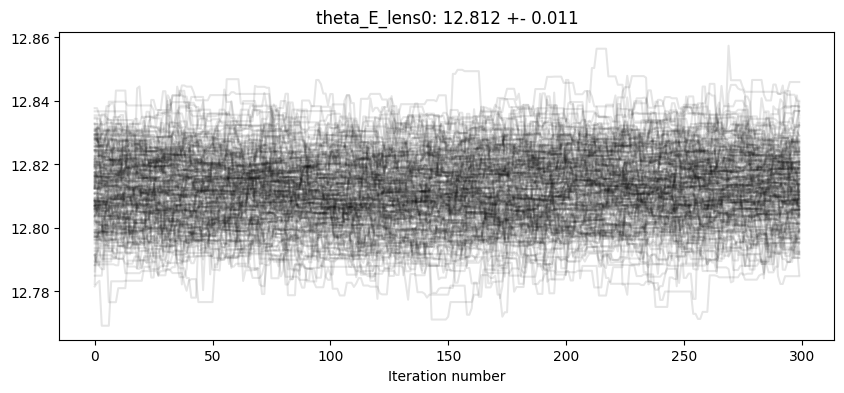

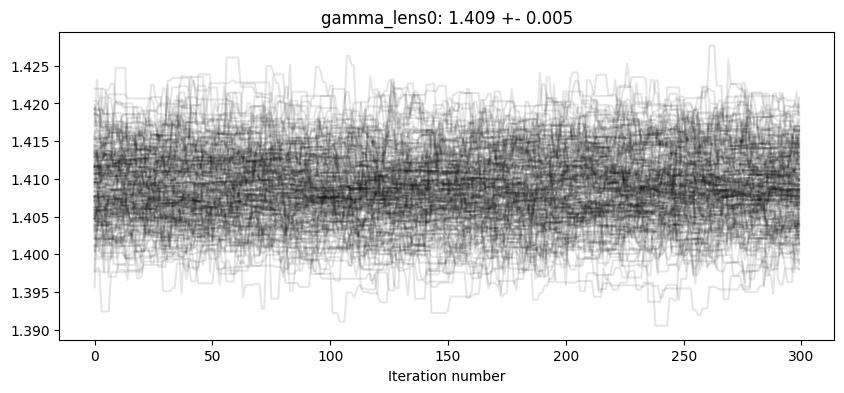

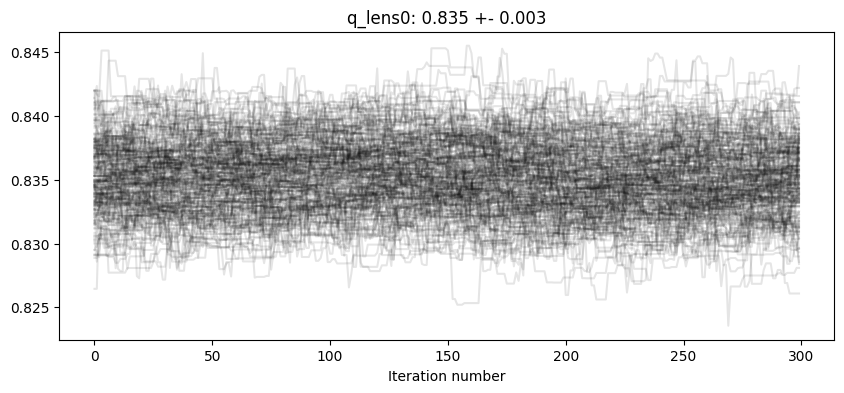

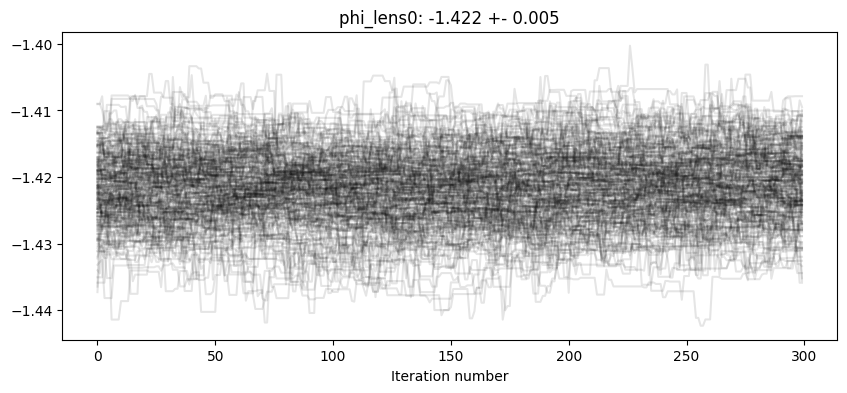

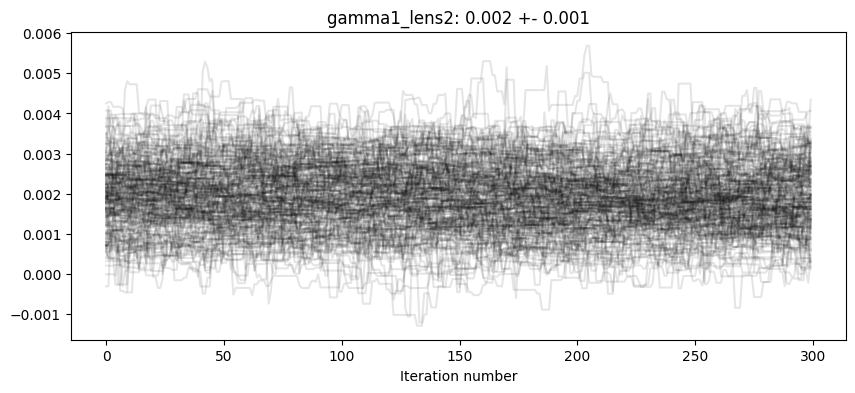

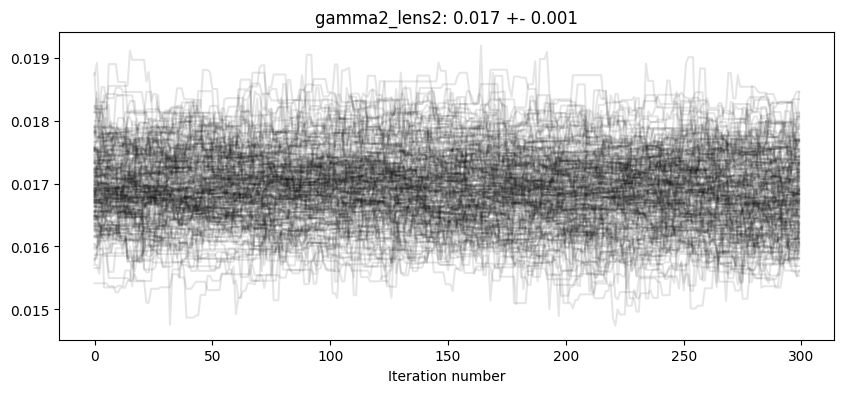

(6, 67200)

In [11]:
want = [
    "theta_E_lens0",
    "gamma_lens0",
    "q_lens0",
    "phi_lens0",
    "gamma1_lens2",
    "gamma2_lens2",
]
indices = [np.where(np.array(param_mcmc) == n)[0][0] for n in want]

samples_mcmc_t = samples_mcmc[-n_walkers * 300 :, :]
gl_stat = np.array([samples_mcmc_t[i::n_walkers, :] for i in np.arange(n_walkers)])

walker_samp = prune_mcmc_chains(
    gl_stat, split=False, deviation_threshold=4, stagnancy_threshold=0.01
)
all_vals = []

for i in indices:
    sub_want = []
    plt.figure(figsize=(10, 4))

    sp = walker_samp[:, :, i]

    for walker in range(sp.shape[0]):
        wal_chain = sp[walker, :]
        sub_want += list(wal_chain)
        plt.plot(wal_chain, alpha=0.1, c="black")

    all_vals += [sub_want]

    plt.xlabel("Iteration number")
    plt.title(f"{param_mcmc[i]}: {np.mean(sp):.3f} +- {np.std(sp):.3f}")
    plt.show()
all_vals = np.array(all_vals)
all_vals.shape

-4.047616495636122 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  4.047616495636124


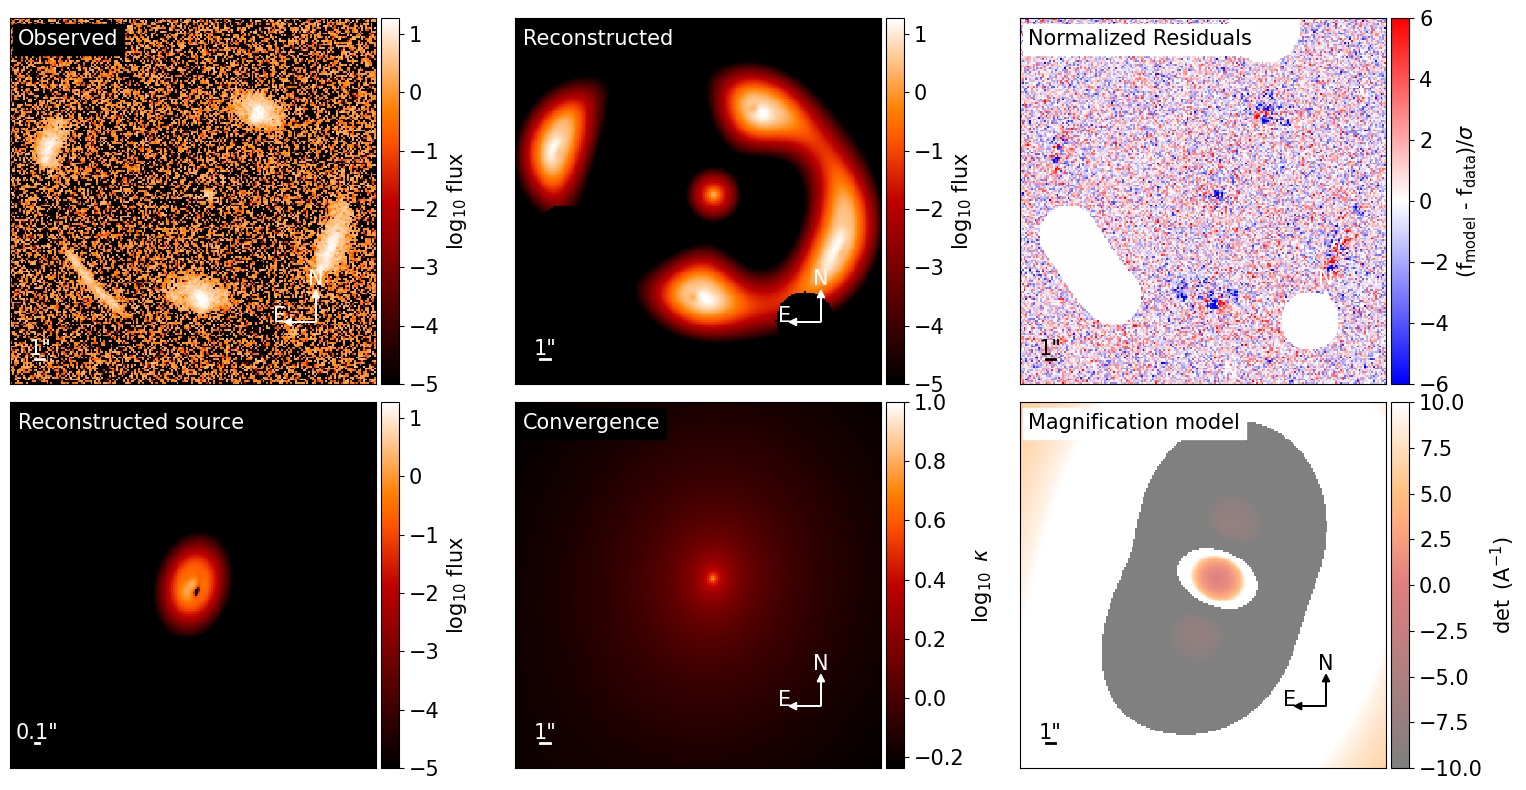

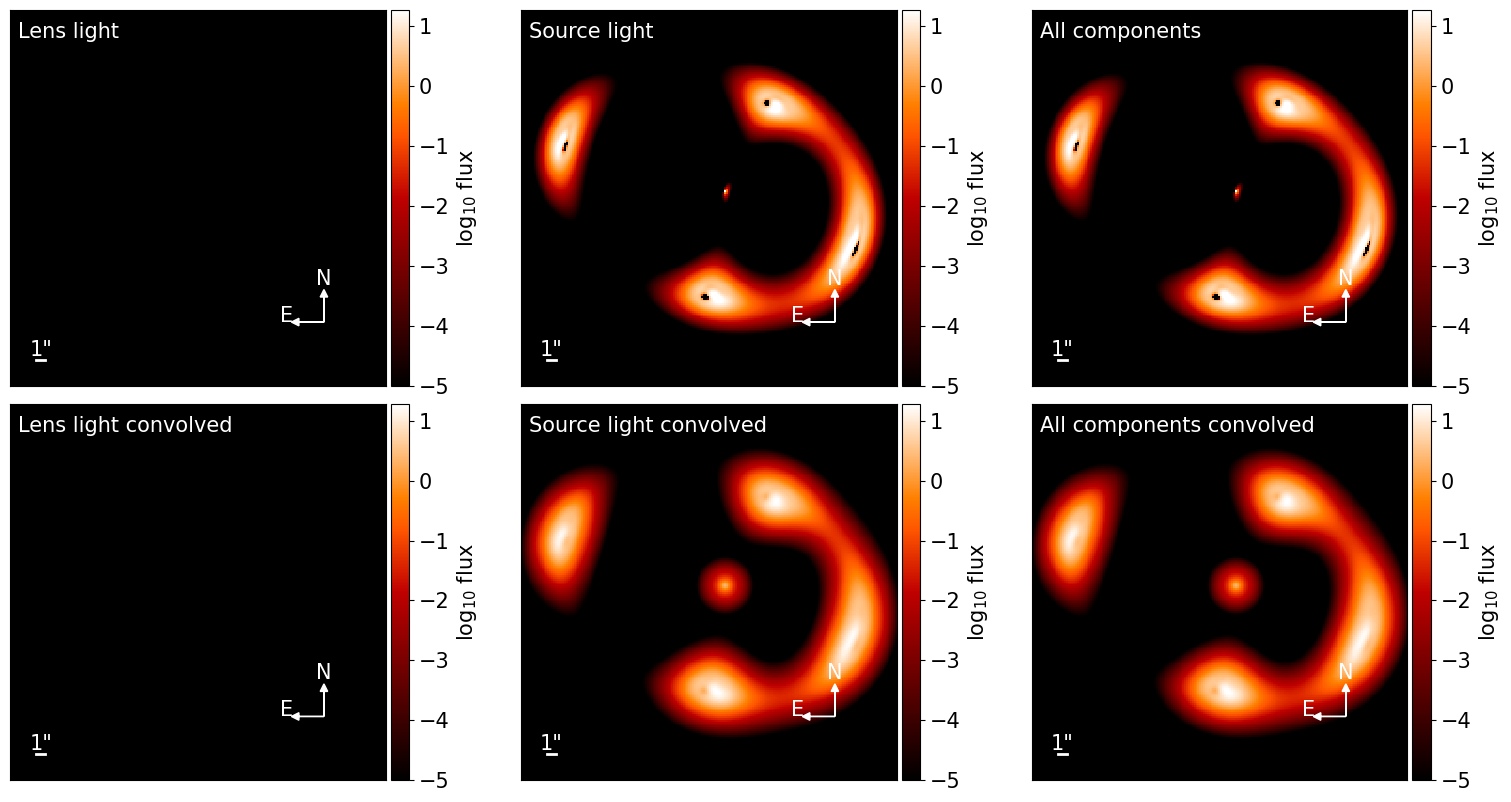

{'kwargs_lens': [{'theta_E': np.float64(12.808430691014514), 'gamma': np.float64(1.4073672532501973), 'q': np.float64(0.835664027296848), 'phi': np.float64(-1.420996293262554), 'center_x': np.float64(-0.744572243040177), 'center_y': np.float64(-0.1823338149584454)}, {'theta_E': np.float64(1.5876356460893257), 'center_x': np.float64(27.399999567933264), 'center_y': np.float64(-28.999999808979737)}, {'gamma1': np.float64(0.0017750654249659907), 'gamma2': np.float64(0.01664400559987519), 'ra_0': 0, 'dec_0': 0}], 'kwargs_source': [{'amp': 1, 'R_sersic': np.float64(0.2322927400030886), 'n_sersic': np.float64(0.6576814731226739), 'e1': np.float64(-0.1459515334096901), 'e2': np.float64(-0.08026593596103705), 'center_x': np.float64(0.8430607273265899), 'center_y': np.float64(-1.1650380045279738)}, {'amp': 1, 'n_max': 3, 'beta': np.float64(0.14393591179724483), 'e1': np.float64(-0.1459515334096901), 'e2': np.float64(-0.08026593596103705), 'center_x': np.float64(0.8430607273265899), 'center_y': 

In [12]:
modelPlot = ModelPlot(
    fitting_seq.multi_band_list,
    kwargs_model,
    fitting_seq.best_fit(),
    arrow_size=0.02,
    cmap_string="gist_heat",
    linear_solver=kwargs_constraints.get("linear_solver", True),
    image_likelihood_mask_list=np.array([imset4.mask]),
)

# multi_band_list_sim = copy.deepcopy(multi_band_list)
psfk_f160w_init = fitting_seq.multi_band_list[0][1]
# multi_band_list_sim[0][1] = psfk_f475x

f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)

modelPlot.data_plot(ax=axes[0, 0])
modelPlot.model_plot(ax=axes[0, 1])
modelPlot.normalized_residual_plot(ax=axes[0, 2], v_min=-6, v_max=6)
modelPlot.source_plot(ax=axes[1, 0], deltaPix_source=0.05, numPix=200)
modelPlot.convergence_plot(ax=axes[1, 1], v_max=1)
modelPlot.magnification_plot(ax=axes[1, 2])
f.tight_layout()
f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.0, hspace=0.05)
plt.show()

f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)

modelPlot.decomposition_plot(
    ax=axes[0, 0], text="Lens light", lens_light_add=True, unconvolved=True
)
modelPlot.decomposition_plot(
    ax=axes[1, 0], text="Lens light convolved", lens_light_add=True
)
modelPlot.decomposition_plot(
    ax=axes[0, 1], text="Source light", source_add=True, unconvolved=True
)
modelPlot.decomposition_plot(
    ax=axes[1, 1], text="Source light convolved", source_add=True
)
modelPlot.decomposition_plot(
    ax=axes[0, 2],
    text="All components",
    source_add=True,
    lens_light_add=True,
    unconvolved=True,
)
modelPlot.decomposition_plot(
    ax=axes[1, 2],
    text="All components convolved",
    source_add=True,
    lens_light_add=True,
    point_source_add=True,
)
f.tight_layout()
f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.0, hspace=0.05)
plt.show()

print(fitting_seq.best_fit())
# print(get_p_value(fitting_seq, kwargs_model, mask))

In [13]:
param_for_corner = [
    r"$\theta_{\rm E}$",
    r"$\gamma$",
    r"$q_{\rm m}$",
    r"$\phi_{\rm m}$",
    r"$\gamma_{\rm ext}$",
    r"$\phi_{\rm ext}$",
]

# phis, qs = param_util.ellipticity2phi_q(all_vals[2], all_vals[3])
gamma_phis, gamma_exts = param_util.shear_cartesian2polar(all_vals[4], all_vals[5])

final_dict_res_t = {}
final_dict_res_t[param_for_corner[0]] = copy.deepcopy(all_vals[0])
final_dict_res_t[param_for_corner[1]] = copy.deepcopy(all_vals[1])
final_dict_res_t[param_for_corner[2]] = copy.deepcopy(all_vals[2])
final_dict_res_t[param_for_corner[3]] = copy.deepcopy(all_vals[3]) * 180 / np.pi
final_dict_res_t[param_for_corner[4]] = copy.deepcopy(gamma_exts)
final_dict_res_t[param_for_corner[5]] = copy.deepcopy(gamma_phis)

In [14]:
flatmodel4.init_fitting_seq = fitting_seq
flatmodel4.init_fit = kwargs_result
with open("s4_models/flatshapeletsmodel4.pickle", "wb") as handle:
    pickle.dump(flatmodel4, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [15]:
with open("s4_models/flatshapelets_chains.pickle", "wb") as handle:
    pickle.dump(final_dict_res_t, handle, protocol=pickle.HIGHEST_PROTOCOL)